# 📊 Portfolio Optimization and Risk Analysis Tool

This interactive cell builds a complete **Mean–Variance Portfolio Optimization** environment using `yfinance`, `numpy`, `pandas`, `scipy`, and `ipywidgets`.  
It allows the user to download historical price data, compute annualized returns and covariances, and visualize optimal portfolios and risk metrics.

**Main features:**

1. **Widget Interface** – Interactive sliders and input fields let the user define:
   - The number of historical months to use,
   - Total capital (€),
   - Confidence level for Value at Risk (VaR),
   - Minimum acceptable return \( m_0 \),
   - and the list of stock tickers.

2. **Automatic Data Retrieval** – Downloads adjusted closing prices from **Yahoo Finance** for all selected tickers and computes daily percentage returns.

3. **Portfolio Optimization** – Uses numerical optimization (`scipy.optimize.minimize`) to construct:
   - Minimum Variance Portfolio,  
   - Maximum Sharpe Ratio Portfolio,  
   - Minimum Variance Portfolio with return ≥ \( m_0 \),  
   - and the **Efficient Frontier** curve.

4. **Risk Analysis** – Calculates **daily Value at Risk (VaR)** for each optimized portfolio, based on the selected confidence level and capital amount.

5. **Visualization & Output** –
   - Plots the Efficient Frontier and marks each key portfolio point.
   - Displays portfolio weights, returns, volatilities, and VaR values.
   - Generates LaTeX tables for annualized returns and covariance matrices, ready to include in reports or papers.

This cell combines quantitative finance, optimization, and risk management tools into a single interactive environment that is fully compatible with **Google Colab**.


In [1]:
# ----------------------
# Απαιτούμενα πακέτα
# (Σε Colab: !pip install yfinance ipywidgets matplotlib numpy pandas scipy)
# ----------------------
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from scipy.optimize import minimize
from scipy.stats import norm
import ipywidgets as widgets
from IPython.display import display

# ----------------------------------------
# Συνάρτηση Εξαγωγής σε LaTeX
# ----------------------------------------
def export_to_latex(annual_returns, annual_cov_matrix, tickers):
    """
    Εξάγει τους πίνακες των ετήσιων αποδόσεων και της συνδιακύμανσης σε LaTeX format.
    Επιστρέφει δύο συμβολοσειρές: LaTeX πίνακας αποδόσεων και συνδιακύμανσης.
    """
    # --- Πίνακας Ετήσιων Αποδόσεων ---
    returns_df = pd.DataFrame({
        "Ticker": tickers,
        "Annual Return": [annual_returns[t] for t in tickers]
    }).set_index("Ticker")

    latex_returns = returns_df.to_latex(
        float_format="%.6f",
        caption="Ετήσιες Αποδόσεις Μετοχών",
        label="tab:annual_returns",
        escape=False
    )

    # --- Πίνακας Συνδιακύμανσης ---
    cov_df = pd.DataFrame(annual_cov_matrix, index=tickers, columns=tickers)
    latex_cov = cov_df.to_latex(
        float_format="%.6f",
        caption="Πίνακας Ετήσιας Συνδιακύμανσης",
        label="tab:annual_covariance",
        escape=False
    )

    return latex_returns, latex_cov


# ----------------------
# Widgets για είσοδο
# ----------------------
months_slider = widgets.IntSlider(
    value=12,
    min=1,
    max=600,
    step=1,
    description='Μήνες Παρελθοντικών Δεδομένων:',
    continuous_update=False
)

capital_input = widgets.FloatText(
    value=100000,
    description='Κεφάλαιο (€):',
    disabled=False
)

confidence_slider = widgets.FloatSlider(
    value=0.95,
    min=0.8,
    max=0.99,
    step=0.01,
    description='Επίπεδο εμπιστοσύνης:',
    readout_format='.2f'
)

m0_input = widgets.FloatText(
    value=0.05,
    description='Ελάχιστη Απόδοση (m₀):',
    disabled=False
)

stock_input = widgets.Text(
    value='AAPL,MSFT,GOOG,TSLA',
    placeholder='Εισάγετε μετοχές (π.χ. AAPL,MSFT,TSLA)',
    description='Μετοχές:',
    disabled=False
)

button = widgets.Button(description="Υπολογισμός")
output = widgets.Output()


# ----------------------
# Συνάρτηση υπολογισμού
# ----------------------
def calculate(button):
    output.clear_output()

    months_back = months_slider.value
    ticker_input = stock_input.value.strip()
    capital = capital_input.value
    confidence_level = confidence_slider.value
    m0 = m0_input.value

    if not ticker_input:
        with output:
            print("❗Παρακαλώ εισάγετε τουλάχιστον μία μετοχή.")
        return

    tickers_input_order = [t.strip().upper() for t in ticker_input.split(',')]

    end_date = datetime.today() - timedelta(days=1)
    start_date = end_date - timedelta(days=months_back * 30)

    with output:
        print(f"Λήψη δεδομένων από {start_date.strftime('%Y-%m-%d')} μέχρι {end_date.strftime('%Y-%m-%d')}")
        print("Tickers (input order):", tickers_input_order)

        try:
            data = yf.download(tickers_input_order, start=start_date, end=end_date)['Close']

            if data.empty:
                print("❗Δεν βρέθηκαν δεδομένα.")
                return

            valid_tickers = [col for col in tickers_input_order if col in data.columns]
            if not valid_tickers:
                print("❗Δεν βρέθηκαν δεδομένα για κανένα ticker.")
                return

            data = data[valid_tickers]
            returns = data.pct_change().dropna()

            annual_returns = returns.mean() * 252
            annual_cov_matrix = returns.cov() * 252
            num_assets = len(valid_tickers)

            # --- Εκτύπωση Ετήσιων Αποδόσεων και Συνδιακύμανσης ---
            print("\n📈 Ετήσιες Αποδόσεις Μετοχών:")
            for ticker in valid_tickers:
                print(f"{ticker}: {annual_returns[ticker]:.4f} ({annual_returns[ticker]*100:.2f}%)")

            print("\n📊 Πίνακας Ετήσιας Συνδιακύμανσης:")
            cov_df = pd.DataFrame(annual_cov_matrix, index=valid_tickers, columns=valid_tickers)
            display(cov_df.style.format("{:.6f}").set_caption("Annual Covariance Matrix"))

            # ---------------------------------------
            # Βοηθητικές συναρτήσεις
            # ---------------------------------------
            def portfolio_stats(weights, mean_returns, cov_matrix):
                portfolio_return = np.sum(mean_returns * weights)
                portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
                return portfolio_return, portfolio_volatility

            def minimize_volatility(weights, mean_returns, cov_matrix):
                return portfolio_stats(weights, mean_returns, cov_matrix)[1]

            def neg_sharpe_ratio(weights, mean_returns, cov_matrix, risk_free_rate=0):
                ret, vol = portfolio_stats(weights, mean_returns, cov_matrix)
                sharpe = (ret - risk_free_rate) / vol
                return -sharpe

            constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
            bounds = tuple((0, 1) for _ in range(num_assets))
            initial_guess = [1. / num_assets] * num_assets

            # 1️⃣ Minimum Variance Portfolio
            res_min_var = minimize(minimize_volatility, initial_guess,
                                   args=(annual_returns, annual_cov_matrix),
                                   method='SLSQP', bounds=bounds, constraints=constraints)
            min_var_weights = res_min_var.x
            min_ret, min_vol = portfolio_stats(min_var_weights, annual_returns, annual_cov_matrix)

            # 2️⃣ Optimal (Maximum Sharpe Ratio) Portfolio
            res_opt = minimize(neg_sharpe_ratio, initial_guess,
                               args=(annual_returns, annual_cov_matrix, 0),
                               method='SLSQP', bounds=bounds, constraints=constraints)
            opt_weights = res_opt.x
            opt_ret, opt_vol = portfolio_stats(opt_weights, annual_returns, annual_cov_matrix)

            # 3️⃣ Min Variance Portfolio με Απόδοση ≥ m₀
            constraints_m0 = (
                {'type': 'eq', 'fun': lambda x: np.sum(x) - 1},
                {'type': 'ineq', 'fun': lambda x: np.sum(x * annual_returns) - m0}
            )
            res_min_var_m0 = minimize(minimize_volatility, initial_guess,
                                      args=(annual_returns, annual_cov_matrix),
                                      method='SLSQP', bounds=bounds, constraints=constraints_m0)
            min_var_m0_weights = res_min_var_m0.x
            min_m0_ret, min_m0_vol = portfolio_stats(min_var_m0_weights, annual_returns, annual_cov_matrix)

            # 4️⃣ Efficient Frontier
            target_returns = np.linspace(min(annual_returns), max(annual_returns), 50)
            frontier_vols = []

            for r in target_returns:
                constraints_frontier = (
                    {'type': 'eq', 'fun': lambda x: np.sum(x) - 1},
                    {'type': 'eq', 'fun': lambda x: np.sum(x * annual_returns) - r}
                )
                res = minimize(minimize_volatility, initial_guess,
                               args=(annual_returns, annual_cov_matrix),
                               method='SLSQP', bounds=bounds, constraints=constraints_frontier)
                if res.success:
                    frontier_vols.append(portfolio_stats(res.x, annual_returns, annual_cov_matrix)[1])
                else:
                    frontier_vols.append(np.nan)

            # 5️⃣ Value at Risk (VaR)
            z_score = norm.ppf(1 - confidence_level)
            var_opt_daily = -(opt_ret / 252 + z_score * (opt_vol / np.sqrt(252)))
            var_min_daily = -(min_ret / 252 + z_score * (min_vol / np.sqrt(252)))
            var_min_m0_daily = -(min_m0_ret / 252 + z_score * (min_m0_vol / np.sqrt(252)))

            var_opt_eur = capital * var_opt_daily
            var_min_eur = capital * var_min_daily
            var_min_m0_eur = capital * var_min_m0_daily

            # 6️⃣ Διάγραμμα Efficient Frontier
            plt.figure(figsize=(10, 6))
            plt.plot(frontier_vols, target_returns, color='gray', lw=2, label='Efficient Frontier')
            plt.scatter(min_vol, min_ret, color='blue', marker='o', s=100, label='Min Variance')
            plt.scatter(opt_vol, opt_ret, color='red', marker='*', s=200, label='Optimal (Sharpe)')
            plt.scatter(min_m0_vol, min_m0_ret, color='green', marker='s', s=120,
                        label=f'Min Var (≥ {m0:.2%})')
            plt.xlabel('Annual Risk (Volatility)')
            plt.ylabel('Annual Return')
            plt.title('Efficient Frontier with Constraints')
            plt.legend()
            plt.grid(True)
            plt.show()

            # 7️⃣ Εκτύπωση Αποτελεσμάτων
            print("\n\n📌 Βέλτιστο Πορτοφόλιο (Sharpe Ratio):")
            for ticker, weight in zip(valid_tickers, opt_weights):
                print(f"{ticker}: {weight:.4f} ({weight*100:.2f}%)")
            print(f"\nΑπόδοση: {opt_ret:.4f} ({opt_ret*100:.2f}%)  |  Volatility: {opt_vol:.4f} ({opt_vol*100:.2f}%)")
            print(f"Ημερήσιο VaR σε €: €{-var_opt_eur:.2f}")

            print("\n📘 Χαρτοφυλάκιο Ελάχιστης Διακύμανσης:")
            for ticker, weight in zip(valid_tickers, min_var_weights):
                print(f"{ticker}: {weight:.4f} ({weight*100:.2f}%)")
            print(f"\nΑπόδοση: {min_ret:.4f} ({min_ret*100:.2f}%)  |  Volatility: {min_vol:.4f} ({min_vol*100:.2f}%)")
            print(f"Ημερήσιο VaR σε €: €{-var_min_eur:.2f}")

            print("\n📗 Χαρτοφυλάκιο Ελάχιστης Διακύμανσης με Απόδοση ≥ m₀:")
            for ticker, weight in zip(valid_tickers, min_var_m0_weights):
                print(f"{ticker}: {weight:.4f} ({weight*100:.2f}%)")
            print(f"\nΑπόδοση: {min_m0_ret:.4f} ({min_m0_ret*100:.2f}%)  |  Volatility: {min_m0_vol:.4f} ({min_m0_vol*100:.2f}%)")
            print(f"Ημερήσιο VaR σε €: €{-var_min_m0_eur:.2f}")

            # 8️⃣ Εξαγωγή σε LaTeX
            latex_returns, latex_cov = export_to_latex(annual_returns, annual_cov_matrix, valid_tickers)
            print("\n📄 --- LaTeX Πίνακας Αποδόσεων ---")
            print(latex_returns)
            print("\n📄 --- LaTeX Πίνακας Συνδιακύμανσης ---")
            print(latex_cov)

        except Exception as e:
            print("Σφάλμα:", str(e))


# ----------------------
# Σύνδεση κουμπιού
# ----------------------
button.on_click(calculate)

# ----------------------
# Εμφάνιση interface
# ----------------------
display(
    months_slider,
    capital_input,
    confidence_slider,
    m0_input,
    stock_input,
    button,
    output
)


IntSlider(value=12, continuous_update=False, description='Μήνες Παρελθοντικών Δεδομένων:', max=600, min=1)

FloatText(value=100000.0, description='Κεφάλαιο (€):')

FloatSlider(value=0.95, description='Επίπεδο εμπιστοσύνης:', max=0.99, min=0.8, step=0.01)

FloatText(value=0.05, description='Ελάχιστη Απόδοση (m₀):')

Text(value='AAPL,MSFT,GOOG,TSLA', description='Μετοχές:', placeholder='Εισάγετε μετοχές (π.χ. AAPL,MSFT,TSLA)'…

Button(description='Υπολογισμός', style=ButtonStyle())

Output()

# 🧮 Option Data Fetcher – Step 1: Stock and Option Selection

This cell allows the user to interactively select multiple stock tickers, view their current market prices, and explore available option contracts using **Yahoo Finance** data.  

It performs the following steps:

1. **Ticker Selection** – The user enters one or more tickers (e.g., `AAPL, MSFT, GOOG`).  
2. **Stock Prices** – The script automatically retrieves and displays the latest closing price for each stock.  
3. **Common Expiration Dates** – Only the expiration dates available for **all** selected tickers are shown, ensuring consistency when comparing options.  
4. **Option Chains** – For the chosen expiration date, the program displays a complete list of available **strike prices** along with their **Call** and **Put** premiums.  
5. **User Input** – The user selects one Call and one Put strike for each ticker.  
6. **Data Summary** – A summary table of all selected parameters (spot price, strikes, and option premiums) is displayed and stored in a Python dictionary named `options_data`.

The resulting `options_data` dictionary will be used in the next cell to define payoff coefficients (`a_i`, `b_i`, `c_i`) and compute the profit or loss for each strategy.


In [6]:
# ============================================================
# Cell 1: Επιλογή tickers, κοινής ημερομηνίας λήξης, call & put
# Εμφανίζει ΜΟΝΟ τις κοινές ημερομηνίες λήξης και ΟΛΑ τα strikes
# ============================================================

!pip install yfinance pandas numpy tabulate --quiet
import yfinance as yf
import pandas as pd
import numpy as np
from tabulate import tabulate
from IPython.display import display, HTML

# ------------------------------------------------------------
# 1. Επιλογή tickers και εμφάνιση τρεχουσών τιμών
# ------------------------------------------------------------
tickers = input("Δώσε tickers χωρισμένα με κόμμα (π.χ. AAPL,MSFT,GOOG): ").split(',')
tickers = [t.strip().upper() for t in tickers]

options_data = {}

print("\n📈 Τρέχουσες τιμές μετοχών:")
stock_prices = []
for t in tickers:
    tk = yf.Ticker(t)
    S0 = tk.history(period="1d")['Close'].iloc[-1]
    stock_prices.append([t, f"{S0:.2f}"])
print(tabulate(stock_prices, headers=["Ticker", "Τιμή ($)"], tablefmt="fancy_grid"))

# ------------------------------------------------------------
# 2. Εύρεση ΜΟΝΟ κοινών ημερομηνιών λήξης
# ------------------------------------------------------------
all_exp = {}
for t in tickers:
    tk = yf.Ticker(t)
    expirations = tk.options
    all_exp[t] = set(expirations)
    print(f"\n📅 {t}: {len(expirations)} διαθέσιμες ημερομηνίες")

# Υπολογισμός τομής όλων των λιστών ημερομηνιών
common_expirations = sorted(list(set.intersection(*all_exp.values())))

if not common_expirations:
    print("\n❌ Δεν υπάρχουν κοινές ημερομηνίες λήξης για όλα τα tickers.")
    raise SystemExit

print("\n✅ Κοινές ημερομηνίες λήξης για όλα τα tickers:")
for e in common_expirations:
    print("   •", e)

common_exp = input("\nΕπέλεξε κοινή ημερομηνία λήξης από τη λίστα παραπάνω: ").strip()
if common_exp not in common_expirations:
    raise ValueError("Η ημερομηνία που δόθηκε δεν είναι κοινή!")

# ------------------------------------------------------------
# 3. Προβολή ΟΛΩΝ των strikes και premiums για κάθε ticker
# ------------------------------------------------------------
for t in tickers:
    tk = yf.Ticker(t)
    chain = tk.option_chain(common_exp)
    calls, puts = chain.calls, chain.puts

    print(f"\n═══════════════════════════════════════════════════════════════")
    print(f"📊 Πληροφορίες για {t} (λήξη {common_exp})")
    print("Τρέχουσα τιμή:", round(tk.history(period='1d')['Close'].iloc[-1], 2), "USD")

    # Συνένωση call & put δεδομένων για πλήρη εικόνα
    merged = pd.DataFrame({
        "Strike": calls['strike'],
        "Call_Premium": calls['lastPrice'],
        "Put_Premium": puts['lastPrice']
    }).sort_values("Strike").reset_index(drop=True).round(2)

    # Εμφάνιση πλήρους πίνακα με scroll (αν είναι μεγάλος)
    display(HTML(merged.to_html(index=False)))

    # Επιλογή strikes από τον χρήστη
    Kc = float(input("Δώσε strike για CALL: "))
    Kp = float(input("Δώσε strike για PUT: "))

    # Εύρεση premiums για τα επιλεγμένα strikes
    C_price = float(calls.loc[calls['strike'] == Kc, 'lastPrice'].iloc[0])
    P_price = float(puts.loc[puts['strike'] == Kp, 'lastPrice'].iloc[0])
    S0 = tk.history(period="1d")['Close'].iloc[-1]

    options_data[t] = {
        "S0": S0,
        "K_call": Kc, "K_put": Kp,
        "C_price": C_price, "P_price": P_price
    }

# ------------------------------------------------------------
# 4. Τελική ανασκόπηση επιλογών
# ------------------------------------------------------------
summary = []
for t in tickers:
    d = options_data[t]
    summary.append([t, f"{d['S0']:.2f}", d['K_call'], f"{d['C_price']:.2f}",
                    d['K_put'], f"{d['P_price']:.2f}"])

print("\n✅ Επιλεγμένα δεδομένα:")
print(tabulate(summary, headers=["Ticker", "S0 ($)", "K_call", "Call Premium ($)", "K_put", "Put Premium ($)"], tablefmt="fancy_grid"))

print("\n📦 Τα δεδομένα αποθηκεύτηκαν στο options_data.")
print("➡️ Τώρα μπορείς να τρέξεις το δεύτερο κελί για να υπολογίσεις το κέρδος.")


Δώσε tickers χωρισμένα με κόμμα (π.χ. AAPL,MSFT,GOOG): AAPL,MSFT

📈 Τρέχουσες τιμές μετοχών:
╒══════════╤════════════╕
│ Ticker   │   Τιμή ($) │
╞══════════╪════════════╡
│ AAPL     │     268.96 │
├──────────┼────────────┤
│ MSFT     │     542.03 │
╘══════════╧════════════╛

📅 AAPL: 20 διαθέσιμες ημερομηνίες

📅 MSFT: 20 διαθέσιμες ημερομηνίες

✅ Κοινές ημερομηνίες λήξης για όλα τα tickers:
   • 2025-10-31
   • 2025-11-07
   • 2025-11-14
   • 2025-11-21
   • 2025-11-28
   • 2025-12-05
   • 2025-12-19
   • 2026-01-16
   • 2026-02-20
   • 2026-03-20
   • 2026-04-17
   • 2026-05-15
   • 2026-06-18
   • 2026-08-21
   • 2026-09-18
   • 2026-12-18
   • 2027-01-15
   • 2027-06-17
   • 2027-12-17
   • 2028-01-21

Επέλεξε κοινή ημερομηνία λήξης από τη λίστα παραπάνω: 2026-01-16

═══════════════════════════════════════════════════════════════
📊 Πληροφορίες για AAPL (λήξη 2026-01-16)
Τρέχουσα τιμή: 268.96 USD


Strike,Call_Premium,Put_Premium
5.0,252.00,0.01
10.0,238.78,0.01
15.0,249.22,0.01
20.0,244.27,0.01
25.0,238.82,0.01
30.0,238.65,0.01
35.0,221.72,0.01
40.0,223.28,0.01
45.0,197.13,0.02
50.0,213.56,0.01


Δώσε strike για CALL: 280
Δώσε strike για PUT: 280

═══════════════════════════════════════════════════════════════
📊 Πληροφορίες για MSFT (λήξη 2026-01-16)
Τρέχουσα τιμή: 541.97 USD


Strike,Call_Premium,Put_Premium
160.0,387.25,0.02
165.0,228.00,0.01
170.0,242.37,0.01
175.0,329.22,0.02
180.0,276.06,0.02
185.0,179.55,0.03
190.0,326.24,0.03
195.0,325.60,0.01
200.0,334.10,0.03
205.0,307.05,0.02


Δώσε strike για CALL: 330
Δώσε strike για PUT: 330

✅ Επιλεγμένα δεδομένα:
╒══════════╤══════════╤══════════╤════════════════════╤═════════╤═══════════════════╕
│ Ticker   │   S0 ($) │   K_call │   Call Premium ($) │   K_put │   Put Premium ($) │
╞══════════╪══════════╪══════════╪════════════════════╪═════════╪═══════════════════╡
│ AAPL     │   268.97 │      280 │                8.5 │     280 │             17.24 │
├──────────┼──────────┼──────────┼────────────────────┼─────────┼───────────────────┤
│ MSFT     │   541.88 │      330 │              191.2 │     330 │              0.2  │
╘══════════╧══════════╧══════════╧════════════════════╧═════════╧═══════════════════╛

📦 Τα δεδομένα αποθηκεύτηκαν στο options_data.
➡️ Τώρα μπορείς να τρέξεις το δεύτερο κελί για να υπολογίσεις το κέρδος.


# 💼 Option Portfolio Payoff Analyzer – Step 2: Profit Computation

This cell computes the **net profit (Πₙₑₜ)** of a multi-asset option strategy using the market data and option parameters selected in the previous step.

**Overview:**

1. **Coefficient Input:**  
   For each stock \( S_i \), the user enters three coefficients:  
   - \( a_i \): number of shares held (long or short),  
   - \( b_i \): number of Call options,  
   - \( c_i \): number of Put options.  
   These define the position weights in the overall portfolio.

2. **Initial Investment:**  
   The script calculates the total cost of the portfolio based on the current stock prices and option premiums.

3. **Symbolic Profit Function:**  
   The cell constructs and displays the analytical expression of the net profit function  
   \[
   \Pi_{\text{net}}(x_1, \ldots, x_n)
   \]
   using **MathJax**, showing how the profit depends on the future stock prices.

4. **Profit Evaluation:**  
   It defines the function \( \Pi_{\text{net}}(x) \) numerically, including:  
   - linear gains/losses from shares,  
   - payoff from Calls and Puts,  
   - and initial costs for all positions.

5. **Optimization (Profit Minimum):**  
   The script searches for the **minimum possible profit** under $ S_i \ge 0 $:  
   - Uses `scipy.optimize.minimize` (L-BFGS-B) for continuous optimization,  
   - Then performs a dense **grid search** to verify the global minimum.

6. **Results & Visualization:**  
   - Prints the total investment and the minimum profit value.  
   - For one or two assets, it visualizes the profit function:
     - **1 asset:** line plot of Πₙₑₜ vs stock price.  
     - **2 assets:** contour plot of the two-dimensional profit surface.

This step enables users to explore the payoff structure and risk exposure of complex option portfolios, combining analytical formulas, numerical optimization, and visual analysis.



Εισαγωγή συμβολαίων για AAPL:
a_i (μετοχές): 1
b_i (calls): 0
c_i (puts): 40

Εισαγωγή συμβολαίων για MSFT:
a_i (μετοχές): 1
b_i (calls): 0
c_i (puts): 100

💰 Συνολικό αρχικό ποσό επένδυσης:
1520.45 $


<IPython.core.display.Math object>


💰 Συνολικό ποσό επένδυσης: 1520.45 $

🔹 Ακριβές ελάχιστο (grid search, S_i ≥ 0):
AAPL: S* = 384.24
MSFT: S* = 387.06
Π_min (exact) = -749.15


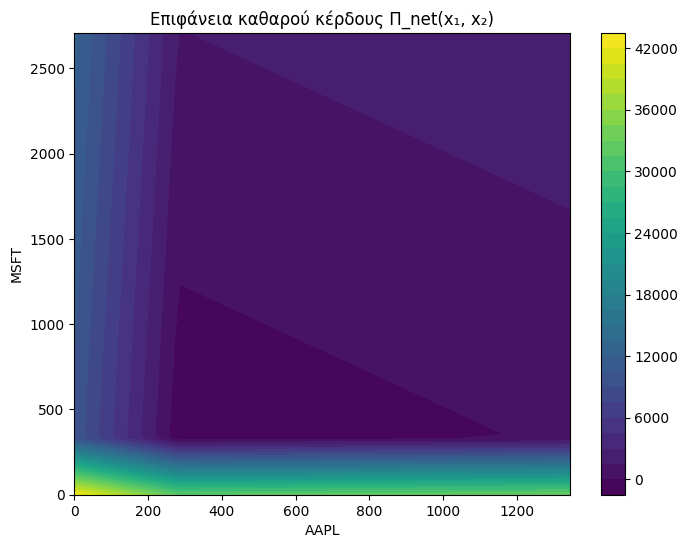

In [7]:
# ============================================================
# Cell 2: Επιλογή a_i, b_i, c_i και υπολογισμός κέρδους
# για S_i ≥ 0
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from itertools import product
from IPython.display import display, Math

# ------------------------------------------------------------
# 1. Είσοδος συντελεστών a_i, b_i, c_i
# ------------------------------------------------------------
a, b, c = [], [], []
for t in tickers:
    print(f"\nΕισαγωγή συμβολαίων για {t}:")
    a_i = float(input("a_i (μετοχές): "))
    b_i = float(input("b_i (calls): "))
    c_i = float(input("c_i (puts): "))
    a.append(a_i)
    b.append(b_i)
    c.append(c_i)

a, b, c = np.array(a), np.array(b), np.array(c)

# ------------------------------------------------------------
# 2. Υπολογισμός συνολικού κόστους επένδυσης
# ------------------------------------------------------------
total_investment = 0.0
for i, t in enumerate(tickers):
    S0 = options_data[t]["S0"]
    C = options_data[t]["C_price"]
    P = options_data[t]["P_price"]
    total_investment += a[i]*S0 + b[i]*C + c[i]*P

print("\n💰 Συνολικό αρχικό ποσό επένδυσης:")
print(f"{total_investment:.2f} $")

# ------------------------------------------------------------
# 3. MathJax εμφάνιση της συνάρτησης Π_net
# ------------------------------------------------------------
profit_latex = r"\Pi_{\text{net}}(x_1,\ldots,x_n) = "
terms = []
for i, t in enumerate(tickers):
    S0 = options_data[t]["S0"]
    Kc = options_data[t]["K_call"]
    Kp = options_data[t]["K_put"]
    C = options_data[t]["C_price"]
    P = options_data[t]["P_price"]
    term = fr"a_{{{i+1}}}(x_{{{i+1}}}-{S0:.2f}) + b_{{{i+1}}}\max(x_{{{i+1}}}-{Kc:.2f},0) + c_{{{i+1}}}\max({Kp:.2f}-x_{{{i+1}}},0) - b_{{{i+1}}}{C:.2f} - c_{{{i+1}}}{P:.2f}"
    terms.append(term)
profit_latex += " + ".join(terms)
display(Math(profit_latex))

# ------------------------------------------------------------
# 4. Συνάρτηση καθαρού κέρδους
# ------------------------------------------------------------
def profit_net(x):
    x = np.array(x)
    total = 0.0
    for i, t in enumerate(tickers):
        S0 = options_data[t]["S0"]
        Kc = options_data[t]["K_call"]
        Kp = options_data[t]["K_put"]
        C = options_data[t]["C_price"]
        P = options_data[t]["P_price"]
        total += (
            a[i]*(x[i]-S0)
            + b[i]*np.maximum(x[i]-Kc,0)
            + c[i]*np.maximum(Kp-x[i],0)
            - b[i]*C
            - c[i]*P
        )
    return total

# ------------------------------------------------------------
# 5. Εύρεση ελαχίστου για S_i ≥ 0 (0 έως 5*S0)
# ------------------------------------------------------------
bounds = [(0, 5*options_data[t]["S0"]) for t in tickers]
x0 = [options_data[t]["S0"] for t in tickers]

# Προσεγγιστικό ελάχιστο με L-BFGS-B
res = minimize(profit_net, x0, bounds=bounds, method='L-BFGS-B')
x_min_opt = res.x
profit_min_opt = profit_net(x_min_opt)

# Grid search (πυκνό πλέγμα 0–5S0)
grid_points = []
for t in tickers:
    S0 = options_data[t]["S0"]
    Kc = options_data[t]["K_call"]
    Kp = options_data[t]["K_put"]
    grid_points.append(np.linspace(0, 5*S0, 8))

min_val = float('inf')
x_min_grid = None
for combo in product(*grid_points):
    val = profit_net(combo)
    if val < min_val:
        min_val = val
        x_min_grid = combo

# ------------------------------------------------------------
# 6. Αποτελέσματα
# ------------------------------------------------------------
print("\n=============================================")
print(f"💰 Συνολικό ποσό επένδυσης: {total_investment:.2f} $")


print("\n🔹 Ακριβές ελάχιστο (grid search, S_i ≥ 0):")
for i, t in enumerate(tickers):
    print(f"{t}: S* = {x_min_grid[i]:.2f}")
print(f"Π_min (exact) = {min_val:.2f}")
print("=============================================")

# ------------------------------------------------------------
# 7. Οπτικοποίηση (για 1 ή 2 tickers)
# ------------------------------------------------------------
if len(tickers) == 1:
    xs = np.linspace(0, 5*options_data[tickers[0]]["S0"], 400)
    ys = [profit_net([x]) for x in xs]
    plt.plot(xs, ys)
    plt.axhline(0, color='black', lw=0.8)
    plt.xlabel("Τιμή μετοχής")
    plt.ylabel("Καθαρό κέρδος Π_net(x)")
    plt.title(f"Π_net(x) για {tickers[0]}")
    plt.grid(True)
    plt.show()

elif len(tickers) == 2:
    X = np.linspace(0, 5*options_data[tickers[0]]["S0"], 100)
    Y = np.linspace(0, 5*options_data[tickers[1]]["S0"], 100)
    Z = np.zeros((len(Y), len(X)))
    for i, x1 in enumerate(X):
        for j, x2 in enumerate(Y):
            Z[j,i] = profit_net([x1, x2])
    Xg, Yg = np.meshgrid(X, Y)
    fig = plt.figure(figsize=(8,6))
    cp = plt.contourf(Xg, Yg, Z, 40, cmap='viridis')
    plt.colorbar(cp)
    plt.xlabel(tickers[0])
    plt.ylabel(tickers[1])
    plt.title("Επιφάνεια καθαρού κέρδους Π_net(x₁, x₂)")
    plt.show()


# 📈 CAPM (Capital Asset Pricing Model) Analysis

This cell applies the **Capital Asset Pricing Model (CAPM)** to estimate each stock’s sensitivity to market movements (Beta), its excess performance over the market (Alpha), and the explanatory power of the model (R²).

**Procedure:**

1. **Data Retrieval**  
   - Downloads daily closing prices for the selected stocks and the S&P 500 index (`^GSPC`).
   - Uses the same historical window (`months_back`) as before.

2. **Return Calculation**  
   - Computes daily returns for assets and market.  
   - Adjusts to *excess returns* by subtracting the daily risk-free rate.

3. **CAPM Regression**  
   The model fitted for each stock is:

   $$
   (r_i - r_f) = \alpha_i + \beta_i (r_m - r_f) + \varepsilon_i
   $$

   where  
   - $\alpha_i$ is the abnormal return (intercept),  
   - $\beta_i$ measures the market risk exposure,  
   - and $r_m - r_f$ is the excess market return.

4. **Results**  
   The table shows **Alpha**, **Beta**, and **R²** for each stock:
   - **Beta > 1** → stock more volatile than the market  
   - **Beta < 1** → less sensitive to market moves  
   - **Alpha > 0** → outperformance vs. CAPM prediction



In [ ]:
# ----------------------------------------
# Εφαρμογή CAPM (Capital Asset Pricing Model)
# ----------------------------------------
import statsmodels.api as sm

# Χρησιμοποίησε ίδιους tickers και μήνες όπως παραπάνω
tickers = ['AAPL', 'MSFT',  'TSLA']   # ή αλλάξτε ανάλογα
months_back = 12

end_date = datetime.today() - timedelta(days=1)
start_date = end_date - timedelta(days=months_back * 30)

# Κατέβασε ξανά τα δεδομένα
data = yf.download(tickers, start=start_date, end=end_date)['Close']
returns = data.pct_change().dropna()

# ----------------------------------------
# Παράμετροι CAPM
# ----------------------------------------
risk_free_rate = 0.02  # 2% ετήσιο επιτόκιο χωρίς κίνδυνο
market_ticker = "^GSPC"  # S&P 500
market_data = yf.download(market_ticker, start=start_date, end=end_date)['Close']
market_returns = market_data.pct_change().dropna()

# Ευθυγράμμιση
aligned_returns = returns.loc[returns.index.intersection(market_returns.index)]
market_returns = market_returns.loc[aligned_returns.index]

rf_daily = (1 + risk_free_rate)**(1/252) - 1
excess_market_return = market_returns - rf_daily

# Εφαρμογή CAPM για κάθε μετοχή
capm_results = {}

for ticker in aligned_returns.columns:
    excess_stock_return = aligned_returns[ticker] - rf_daily
    X = sm.add_constant(excess_market_return)
    model = sm.OLS(excess_stock_return, X).fit()
    alpha, beta = model.params
    capm_results[ticker] = {
        "Alpha": alpha,
        "Beta": beta,
        "R²": model.rsquared
    }

# Εμφάνιση αποτελεσμάτων
capm_df = pd.DataFrame(capm_results).T
capm_df.columns = ["Alpha", "Beta", "R²"]
display(capm_df.style.format({"Alpha": "{:.6f}", "Beta": "{:.4f}", "R²": "{:.3f}"})
                .set_caption("Αποτελέσματα Υποδείγματος CAPM"))


/tmp/ipython-input-2726293132.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start_date, end=end_date)['Close']
[*********************100%***********************]  3 of 3 completed
/tmp/ipython-input-2726293132.py:22: FutureWarning: YF.download() has changed argument auto_adjust default to True
  market_data = yf.download(market_ticker, start=start_date, end=end_date)['Close']
[*********************100%***********************]  1 of 1 completed


,Alpha,Beta,R²
AAPL,-0.000042,1.3005,0.565
MSFT,0.000436,0.9296,0.539
TSLA,0.001481,2.4327,0.460
